# TOPP-HATT

Given some tree, restrict the node and leaf choices of HATT to find the minimum pauli-weight and weighted-pauli-weight tree.

In [23]:
# Import coefficients
import pickle
from ferrmion.encode import TernaryTree
from pathlib import Path

def water_integrals():
    folder = Path.cwd().joinpath(Path("../../../python/tests/"))
    with open(folder.joinpath("./data/water_1e.pkl"), 'rb') as file:
        ones = pickle.load(file)

    with open(folder.joinpath("./data/water_2e.pkl"), 'rb') as file:
        twos = pickle.load(file)
    return (ones, twos)
ones, twos = water_integrals()
twos *= 0.5

In [24]:
"""Code to Geneate Hamiltonian Adaptive Ternary Tree from Majorana Hamiltonian."""

from itertools import permutations
from typing import Iterable

import numpy as np

from ferrmion.encode import TernaryTree
from ferrmion.encode.ternary_tree_node import TTNode

def _reduce_hamiltonian(
    majorana_ham: dict[Iterable[int], float],
    parent_index: int,
    selection: tuple[int, int, int],
) -> dict[tuple[int, ...], float]:
    """Simplify the Hamiltonian.

    As we increase the qubit number, we iteratively remove majoranas
    which act trivially on the remaining qubits.
    We replace them with the index of their parent string
    as going forward they are identical to the parent string.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Current Hamiltonian.
        parent_index (int): Qubit index of the parent node.
        selection (tuple[int, int, int]): Indices of the majoranas to be replaced.

    Returns:
        dict[tuple[int,...],float]: Reduced Hamiltonian.
    """
    new_ham = {}
    for term, coeff in majorana_ham.items():
        # new_term = tuple(i if i not in selection else parent_index for i in term)
        new_term = tuple(i for i in term if i not in selection) + tuple(
            parent_index for i in term if i in selection
        )
        if len(set(new_term)) > 1:
            new_ham[new_term] = new_ham.get(new_term, 0) + coeff
    return new_ham


def fast_hatt(
    majorana_ham: dict[Iterable[int], float],
    n_modes: int,
    coeff_weight: bool = False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.
        coeff_weight (bool): Multiply Pauli-weight by coefficient norm.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
    # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
    # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}

    n_leaves = 2 * n_modes + 1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves + i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = [*range(n_leaves)]
    unassigned.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves + n_modes)}

    total_weight = 0
    for i in range(n_modes + 1):
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]
        previous = [None, None, None]
        # reverse because best is usually at the end
        # reversed_combinations = [c for c in combinations(unassigned, 2)]
        if i == 0:
            comb_iterator = ([n_leaves - 1, i] for i in range(n_leaves - 1)[::-1])
        else:
            comb_iterator = permutations(unassigned, 2)

        for comb in comb_iterator:
            small_y = None
            small_x = None
            # This way x index will be higher term - more often node.
            z_index, x_index = comb
            # x_index, z_index = comb

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                # print("small x is all z")
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                # print("small_y in comb")
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                # print("y index in comb")
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]
            # comb = [int(i) for i in comb]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue
            if comb == previous:
                continue
            previous = comb
            # tc = tuple(comb)
            # if tc in checked:
            #     continue
            # checked.add(tc)

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > key[-1]:
                        continue
                    elif max(comb) < key[0]:
                        continue
                    else:
                        odd_parity_paulis = [
                            sum([t != c for t in key]) % 2 for c in comb
                        ]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > key[-1]:
                        continue
                    elif max(comb) < key[0]:
                        continue
                    else:
                        odd_parity_paulis = [
                            sum([t != c for t in key]) % 2 for c in comb
                        ]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # weight = np.sum(
                #     [_qubit_term_weight(term, comb) for term in majorana_ham.keys()]
                # )
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            elif weight == min_weight:
                #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # would be better to break on zero
            # if weight == 0:
            #     break

        total_weight += min_weight
        # print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned = [u for u in unassigned if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # print(f"{child_index} {nodes[child_index]}")
                # print(f"Child node {char=} with index {child_index=} is node {nodes.get(child_index).qubit_label=}")
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        # unassigned.append(parent_index)
        unassigned = [parent_index] + unassigned

        if i + 1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        # print("START reducing hamiltonian")
        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)
        # print("STOP reducing hamiltonian")

    if len(unassigned) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned=}")

    last_node = nodes[unassigned[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print("Total Weight: ", total_weight)
    return tree


# POC: Jordan-Wigner

For JW we enforce that we start with the node farthest from the root, then each subsequent node is attached as the Z-parent of the previous.

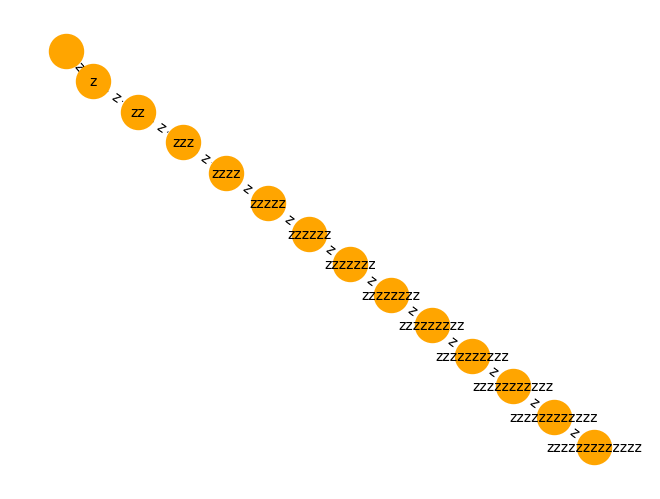

In [25]:
from ferrmion.encode import JordanWigner
from ferrmion.visualise import draw_tt
draw_tt(JordanWigner(14))

In [26]:
def jw_hatt(
    majorana_ham: dict[Iterable[int], float], n_modes: int, coeff_weight:bool=False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}

    n_leaves = 2*n_modes +1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves+ i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = [*range(n_leaves)]
    unassigned.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves  + n_modes)}

    total_weight = 0
    for i in range(n_modes+1):
        print(f"{len(unassigned)=}, {unassigned=}")
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]
        # reverse because best is usually at the end 
        # reversed_combinations = [c for c in combinations(unassigned, 2)]

        z_index = unassigned[0]
        for x_index in unassigned[1:]:
            small_y = None
            small_x = None
            # This way x index will be higher term - more often node.
            # z_index, x_index= comb
            # x_index, z_index = comb
            comb = z_index, x_index

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                # print("small x is all z")
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                # print("small_y in comb")
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                # print("y index in comb")
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]
            # comb = [int(i) for i in comb]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue
            # tc = tuple(comb)
            # if tc in checked:
            #     continue
            # checked.add(tc)

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # weight = np.sum(
                #     [_qubit_term_weight(term, comb) for term in majorana_ham.keys()]
                # ) 
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            elif weight == min_weight:
            #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # would be better to break on zero
            # if weight == 0:
            #     break

        total_weight += min_weight
        # print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned = [ u for u in unassigned if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # print(f"{child_index} {nodes[child_index]}")
                # print(f"Child node {char=} with index {child_index=} is node {nodes.get(child_index).qubit_label=}")
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        # unassigned.append(parent_index)
        unassigned = [parent_index] + unassigned
        
        if i +1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        # print("START reducing hamiltonian")
        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)
        # print("STOP reducing hamiltonian")

    if len(unassigned) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned=}")

    last_node = nodes[unassigned[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print(total_weight)
    return tree

In [27]:
from ferrmion.utils import fermionic_to_sparse_majorana
jw_hatt_tree = jw_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=ones.shape[0], coeff_weight=False)

len(unassigned)=29, unassigned=[28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=27, unassigned=[29, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=25, unassigned=[30, 27, 26, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=23, unassigned=[31, 27, 26, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=21, unassigned=[32, 27, 26, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=19, unassigned=[33, 27, 26, 23, 22, 21, 20, 15, 14, 13, 12, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=17, unassigned=[34, 23, 22, 21, 20, 15, 14, 13, 12, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=15, unassigned=[35, 23, 22, 21, 20, 15, 14, 13, 12, 7, 6, 3, 2, 1, 0]
len(unassigned)=13, unassigned=[36, 23, 22, 21, 20, 15, 14, 7, 6, 3, 2, 1, 0]
len(unassigned)=11, unassigned

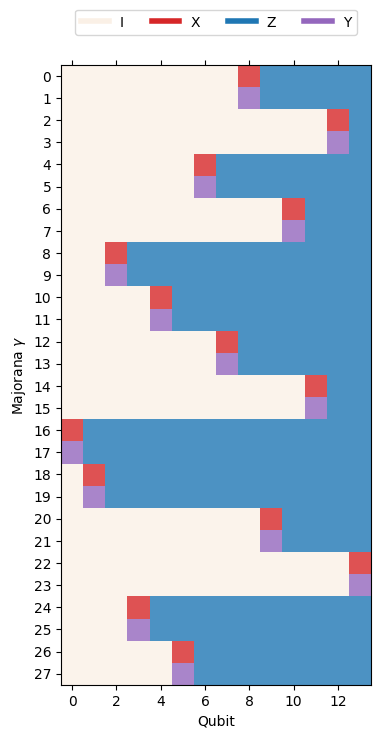

In [28]:
from ferrmion.visualise import symplectic_matshow
symplectic_matshow(jw_hatt_tree._build_symplectic_matrix()[1])

In [29]:
jw_hatt_tree_coeff = jw_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=ones.shape[0], coeff_weight=True)

len(unassigned)=29, unassigned=[28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=27, unassigned=[29, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=25, unassigned=[30, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=23, unassigned=[31, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=21, unassigned=[32, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=19, unassigned=[33, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=17, unassigned=[34, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=15, unassigned=[35, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=13, unassigned=[36, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=11, unassigned=[37, 9, 8, 7, 6

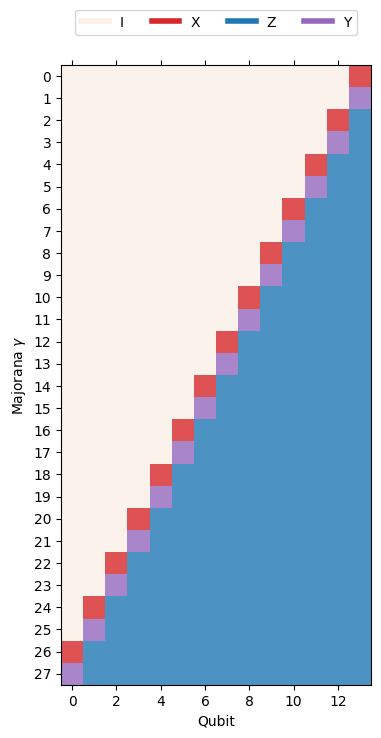

In [30]:
from ferrmion.visualise import symplectic_matshow
symplectic_matshow(jw_hatt_tree_coeff._build_symplectic_matrix()[1])